   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.7 MB/s eta 0:00:00
HMM REGIME-SWITCHING TRADING STRATEGY

PERFORMANCE COMPARISON
----------------------------------------------------------------------
Strategy Total Return : 92.15%
NIFTY Total Return    : 196.63%
Strategy CAGR         : 6.17%
NIFTY CAGR            : 10.48%
Strategy Volatility   : 12.16%
Strategy Sharpe       : 0.56
Strategy Max Drawdown : -34.11%
Days in Market        : 87.83%

REGIME STATISTICS
----------------------------------------------------------------------
         Observations  Mean_Return  Volatility
Regime                                        
Bear             1217      -0.0035     14.4157
Bull             1144       0.1028      9.2415
Neutral           327       0.0289     33.0303

HMM TRANSITION MATRIX
----------------------------------------------------------------------
         State 0  State 1  State 2
State 0 

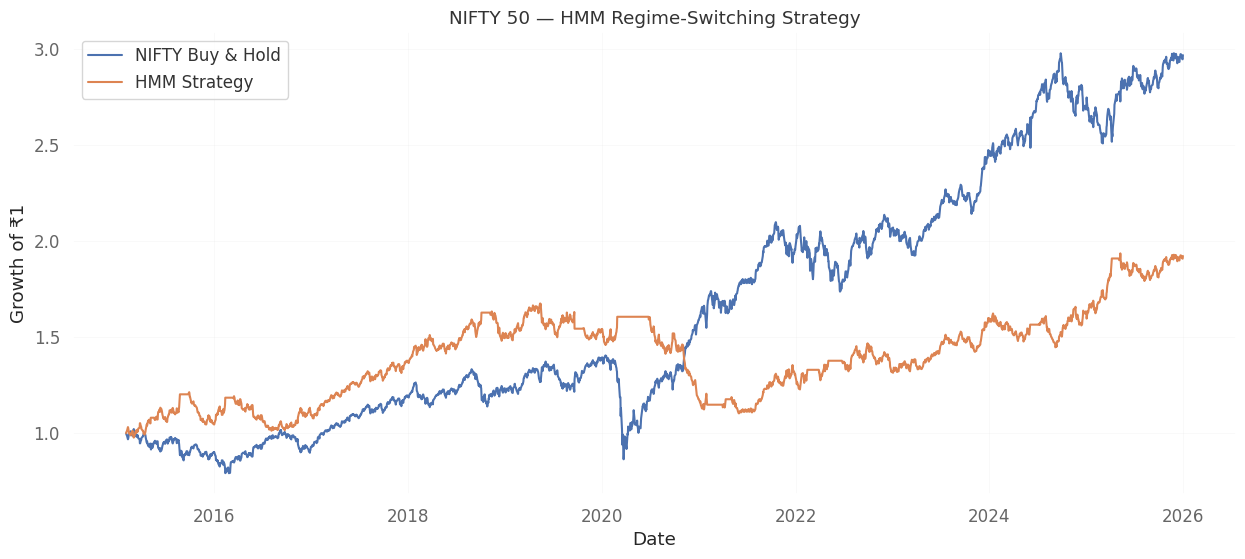

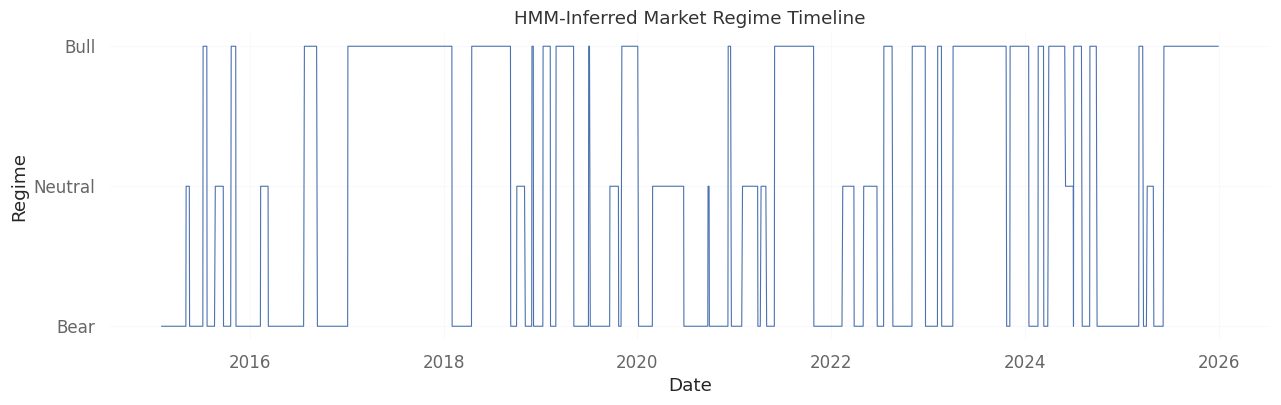

                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2015-02-02
End Period           2025-12-31
Risk-Free Rate       0.0%
Time in Market       88.0%

Cumulative Return    92.15%
CAGR﹪               6.31%

Sharpe               0.56
Prob. Sharpe Ratio   96.74%
Sortino              0.83
Sortino/√2           0.58
Omega                1.11

Max Drawdown         -34.11%
Max DD Date          2021-05-31
Max DD Period Start  2019-05-14
Max DD Period End    2025-01-20
Longest DD Days      2079

Gain/Pain Ratio      0.11
Gain/Pain (1M)       0.51

Payoff Ratio         1.01
Profit Factor        1.11
Common Sense Ratio   1.19
CPC 

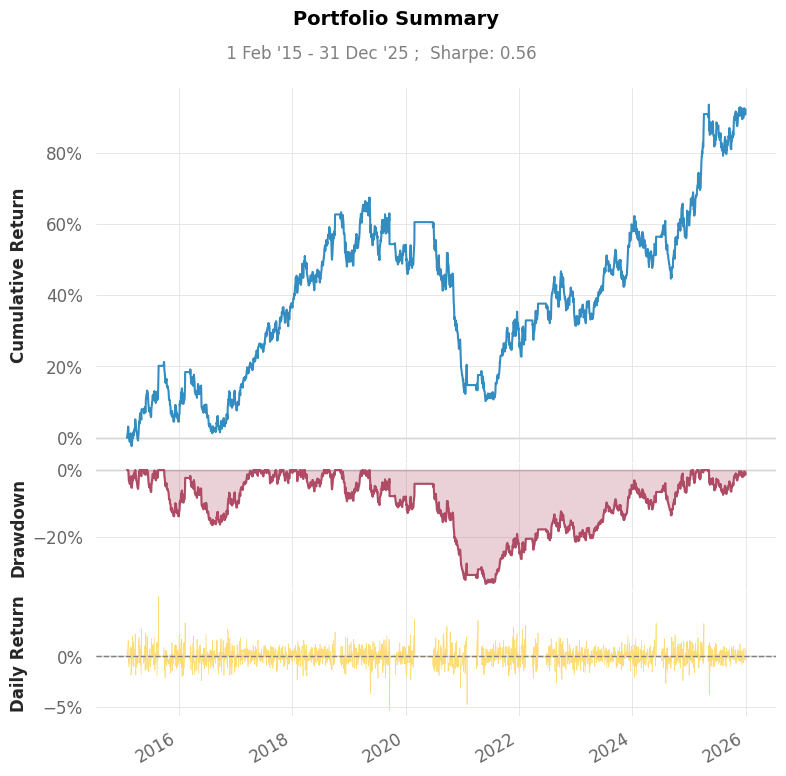

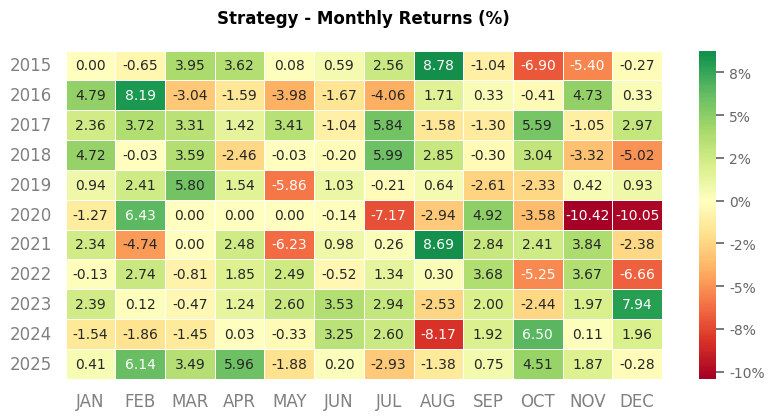


Saved: NIFTY50_HMM_Regime_Switching_Strategy.csv


In [1]:
# ============================================================
# PROJECT 4 — HMM-BASED REGIME-SWITCHING TRADING STRATEGY
# NIFTY 50
# ============================================================

!pip -q install yfinance hmmlearn quantstats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. DOWNLOAD NIFTY 50 DATA
# ------------------------------------------------------------
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

# ------------------------------------------------------------
# 2. CREATE FEATURES
# ------------------------------------------------------------
df["Return"] = df["Close"].pct_change()

df["Volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Momentum"] = (
    df["Close"] /
    df["Close"].rolling(20).mean() - 1
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

features = [
    "Return",
    "Volatility",
    "Momentum"
]

# ------------------------------------------------------------
# 3. STANDARDIZE FEATURES
# ------------------------------------------------------------
scaler = StandardScaler()

X = scaler.fit_transform(
    df[features]
)

# ------------------------------------------------------------
# 4. TRAIN HMM
# ------------------------------------------------------------
n_states = 3

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# ------------------------------------------------------------
# 5. IDENTIFY HIDDEN STATES
# ------------------------------------------------------------
df["State"] = model.predict(X)

probabilities = model.predict_proba(X)

for i in range(n_states):
    df[f"State_{i}_Prob"] = probabilities[:, i]

# ------------------------------------------------------------
# 6. IDENTIFY REGIMES
# ------------------------------------------------------------
state_stats = []

for state in range(n_states):

    data = df[df["State"] == state]

    state_stats.append({
        "State": state,
        "Mean Return": data["Return"].mean(),
        "Volatility": data["Return"].std()
    })

state_stats = pd.DataFrame(state_stats)

# Rank states by mean return
ordered_states = (
    state_stats
    .sort_values("Mean Return")
    ["State"]
    .tolist()
)

# Lowest return = Bear
# Middle = Neutral
# Highest = Bull
regime_names = [
    "Bear",
    "Neutral",
    "Bull"
]

state_mapping = {
    ordered_states[i]: regime_names[i]
    for i in range(n_states)
}

df["Regime"] = df["State"].map(state_mapping)

# ------------------------------------------------------------
# 7. CREATE REGIME-BASED SIGNAL
# ------------------------------------------------------------
# Bull  -> Long
# Neutral -> Flat
# Bear -> Short

signal_map = {
    "Bear": -1,
    "Neutral": 0,
    "Bull": 1
}

df["Signal"] = df["Regime"].map(signal_map)

# ------------------------------------------------------------
# 8. AVOID LOOK-AHEAD BIAS
# ------------------------------------------------------------
# Today's regime is used for tomorrow's return.
df["Strategy_Return"] = (
    df["Signal"].shift(1) *
    df["Return"]
)

df["Strategy_Return"] = (
    df["Strategy_Return"]
    .fillna(0)
)

# ------------------------------------------------------------
# 9. EQUITY CURVES
# ------------------------------------------------------------
df["Buy_Hold_Equity"] = (
    1 + df["Return"]
).cumprod()

df["Strategy_Equity"] = (
    1 + df["Strategy_Return"]
).cumprod()

# ------------------------------------------------------------
# 10. PERFORMANCE METRICS
# ------------------------------------------------------------
strategy_return = (
    df["Strategy_Equity"].iloc[-1] - 1
)

buy_hold_return = (
    df["Buy_Hold_Equity"].iloc[-1] - 1
)

years = (
    (df.index[-1] - df.index[0]).days / 365.25
)

strategy_cagr = (
    df["Strategy_Equity"].iloc[-1] **
    (1 / years) - 1
)

buy_hold_cagr = (
    df["Buy_Hold_Equity"].iloc[-1] **
    (1 / years) - 1
)

strategy_vol = (
    df["Strategy_Return"].std() *
    np.sqrt(252)
)

strategy_sharpe = (
    df["Strategy_Return"].mean() /
    df["Strategy_Return"].std()
) * np.sqrt(252)

strategy_drawdown = (
    df["Strategy_Equity"] /
    df["Strategy_Equity"].cummax() - 1
).min()

# ------------------------------------------------------------
# 11. PRINT RESULTS
# ------------------------------------------------------------
print("=" * 70)
print("HMM REGIME-SWITCHING TRADING STRATEGY")
print("=" * 70)

print("\nPERFORMANCE COMPARISON")
print("-" * 70)

print(
    f"Strategy Total Return : "
    f"{strategy_return * 100:.2f}%"
)

print(
    f"NIFTY Total Return    : "
    f"{buy_hold_return * 100:.2f}%"
)

print(
    f"Strategy CAGR         : "
    f"{strategy_cagr * 100:.2f}%"
)

print(
    f"NIFTY CAGR            : "
    f"{buy_hold_cagr * 100:.2f}%"
)

print(
    f"Strategy Volatility   : "
    f"{strategy_vol * 100:.2f}%"
)

print(
    f"Strategy Sharpe       : "
    f"{strategy_sharpe:.2f}"
)

print(
    f"Strategy Max Drawdown : "
    f"{strategy_drawdown * 100:.2f}%"
)

print(
    f"Days in Market        : "
    f"{(df['Signal'] != 0).mean() * 100:.2f}%"
)

# ------------------------------------------------------------
# 12. REGIME STATISTICS
# ------------------------------------------------------------
print("\nREGIME STATISTICS")
print("-" * 70)

regime_stats = (
    df.groupby("Regime")["Return"]
    .agg(
        Observations="count",
        Mean_Return="mean",
        Volatility="std"
    )
)

regime_stats["Mean_Return"] *= 100
regime_stats["Volatility"] *= np.sqrt(252) * 100

print(
    regime_stats
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# 13. TRANSITION MATRIX
# ------------------------------------------------------------
transition_matrix = pd.DataFrame(
    model.transmat_,
    index=[f"State {i}" for i in range(n_states)],
    columns=[f"State {i}" for i in range(n_states)]
)

print("\nHMM TRANSITION MATRIX")
print("-" * 70)
print(transition_matrix.round(4))

# ------------------------------------------------------------
# 14. EQUITY CURVE
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Buy_Hold_Equity"],
    label="NIFTY Buy & Hold"
)

plt.plot(
    df.index,
    df["Strategy_Equity"],
    label="HMM Strategy"
)

plt.title(
    "NIFTY 50 — HMM Regime-Switching Strategy"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 15. REGIME TIMELINE
# ------------------------------------------------------------
regime_numeric = df["Signal"]

plt.figure(figsize=(15, 4))

plt.plot(
    df.index,
    regime_numeric,
    linewidth=0.8
)

plt.yticks(
    [-1, 0, 1],
    ["Bear", "Neutral", "Bull"]
)

plt.title(
    "HMM-Inferred Market Regime Timeline"
)

plt.xlabel("Date")
plt.ylabel("Regime")

plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 16. QUANTSTATS
# ------------------------------------------------------------
returns = (
    df["Strategy_Return"]
    .copy()
)

returns.index = pd.to_datetime(
    returns.index
)

returns = returns[
    ~returns.index.duplicated()
]

returns = returns.dropna()

try:
    qs.reports.basic(
        returns,
        periods_per_year=252
    )
except Exception as e:
    print("\nQuantStats report skipped:", e)

# ------------------------------------------------------------
# 17. SAVE RESULTS
# ------------------------------------------------------------
df.to_csv(
    "NIFTY50_HMM_Regime_Switching_Strategy.csv"
)

print(
    "\nSaved: "
    "NIFTY50_HMM_Regime_Switching_Strategy.csv"
)